# 🫁 Lung Cancer Dataset — Exploratory Data Analysis

Lung cancer is one of the most prevalent and deadly forms of cancer worldwide. This notebook performs a comprehensive EDA on a lung cancer dataset containing **3000 patient records** with demographic and symptom data.

**Features:** GENDER, AGE, SMOKING, YELLOW_FINGERS, ANXIETY, PEER_PRESSURE, CHRONIC_DISEASE, FATIGUE, ALLERGY, WHEEZING, ALCOHOL_CONSUMING, COUGHING, SHORTNESS_OF_BREATH, SWALLOWING_DIFFICULTY, CHEST_PAIN, LUNG_CANCER

> **Note:** Binary symptom columns use encoding: `1 = Absent`, `2 = Present`

## 1. Import Libraries & Global Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── Global color constants ──────────────────────────────
BG        = '#F8F9FA'
YES_COLOR = '#E74C3C'
NO_COLOR  = '#2ECC71'
PALETTE   = {'YES': YES_COLOR, 'NO': NO_COLOR}

# ── Global column lists ─────────────────────────────────
BINARY_COLS = [
    'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
    'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
    'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH',
    'SWALLOWING_DIFFICULTY', 'CHEST_PAIN'
]

# ── Plot styling ────────────────────────────────────────
plt.rcParams['figure.facecolor'] = BG
plt.rcParams['axes.facecolor']   = BG
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

print('✅ Libraries imported & global config set.')

✅ Libraries imported & global config set.


## 2. Load Dataset

In [2]:
# ── Load your CSV file ──────────────────────────────────
# Change the filename below to match your actual file path
CSV_PATH = 'lung_cancer.csv'   # <── update if needed

df = pd.read_csv("lungs_cancer\dataset.csv")

# Ensure LUNG_CANCER column is uppercase string
df['LUNG_CANCER'] = df['LUNG_CANCER'].str.strip().str.upper()
df['GENDER']      = df['GENDER'].str.strip().str.upper()

# Binary target for correlation analysis
df['LUNG_CANCER_BIN'] = (df['LUNG_CANCER'] == 'YES').astype(int)

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded: 3000 rows × 17 columns


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER,LUNG_CANCER_BIN
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO,0
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO,0
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES,1
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES,1
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO,0
5,F,58,1,1,1,2,2,2,2,1,2,2,1,1,2,YES,1
6,F,70,1,1,1,2,2,1,2,2,2,2,2,2,1,YES,1
7,F,74,2,2,1,1,1,1,2,1,1,1,1,2,1,NO,0
8,M,77,1,2,1,2,1,1,1,1,2,1,1,1,2,NO,0
9,F,67,2,2,2,2,1,2,2,1,2,1,2,1,1,NO,0


## 3. Basic Data Info

In [3]:
print('='*55)
print('DATASET INFO')
print('='*55)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3000 non-null   object
 1   AGE                    3000 non-null   int64 
 2   SMOKING                3000 non-null   int64 
 3   YELLOW_FINGERS         3000 non-null   int64 
 4   ANXIETY                3000 non-null   int64 
 5   PEER_PRESSURE          3000 non-null   int64 
 6   CHRONIC_DISEASE        3000 non-null   int64 
 7   FATIGUE                3000 non-null   int64 
 8   ALLERGY                3000 non-null   int64 
 9   WHEEZING               3000 non-null   int64 
 10  ALCOHOL_CONSUMING      3000 non-null   int64 
 11  COUGHING               3000 non-null   int64 
 12  SHORTNESS_OF_BREATH    3000 non-null   int64 
 13  SWALLOWING_DIFFICULTY  3000 non-null   int64 
 14  CHEST_PAIN             3000 non-null   int64 
 15  LUNG_CAN

In [4]:
print('='*55)
print('DESCRIPTIVE STATISTICS')
print('='*55)
df.describe(include='all')

DESCRIPTIVE STATISTICS


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER,LUNG_CANCER_BIN
count,3000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000,3000.000000
unique,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,YES,NaN
freq,1514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1518,NaN
mean,NaN,55.169000,1.491000,1.514000,1.494000,1.499000,1.509667,1.489667,1.506667,1.497333,1.491333,1.510667,1.488000,1.489667,1.498667,NaN,0.506000
std,NaN,14.723746,0.500002,0.499887,0.500047,0.500082,0.499990,0.499977,0.500039,0.500076,0.500008,0.499970,0.499939,0.499977,0.500082,NaN,0.500047
min,NaN,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,0.000000
25%,NaN,42.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,0.000000
50%,NaN,55.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,NaN,1.000000
75%,NaN,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,NaN,1.000000


In [5]:
print('Missing Values per Column:')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values ✅')
print(f'\nTotal missing cells: {missing.sum()}')

Missing Values per Column:
No missing values ✅

Total missing cells: 0


In [6]:
print('Target Variable Distribution:')
counts = df['LUNG_CANCER'].value_counts()
print(counts.to_string())
print('\nPercentages:')
print((counts / len(df) * 100).round(2).to_string())

Target Variable Distribution:
LUNG_CANCER
YES    1518
NO     1482

Percentages:
LUNG_CANCER
YES    50.6
NO     49.4


## 4. Univariate Analysis

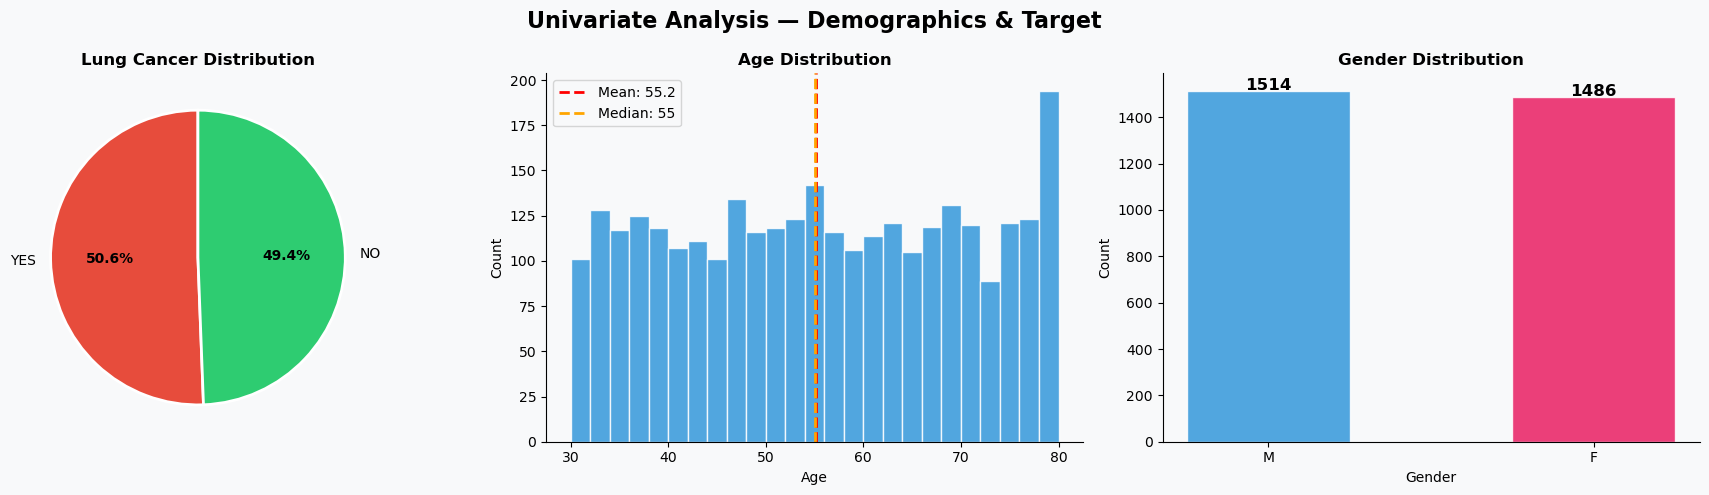

In [7]:
counts = df['LUNG_CANCER'].value_counts()
gender_counts = df['GENDER'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Univariate Analysis — Demographics & Target', fontsize=16, fontweight='bold')

# 1. Target pie
wedges, texts, autotexts = axes[0].pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=[YES_COLOR, NO_COLOR], startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Lung Cancer Distribution', fontweight='bold')

# 2. Age histogram
axes[1].hist(df['AGE'], bins=25, color='#3498DB', edgecolor='white', alpha=0.85)
axes[1].axvline(df['AGE'].mean(),   color='red',    linestyle='--', linewidth=2, label=f"Mean: {df['AGE'].mean():.1f}")
axes[1].axvline(df['AGE'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['AGE'].median():.0f}")
axes[1].set_title('Age Distribution', fontweight='bold')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Count')
axes[1].legend()

# 3. Gender bar chart
bar_colors = ['#3498DB', '#E91E63']
bars = axes[2].bar(gender_counts.index, gender_counts.values,
                   color=bar_colors, edgecolor='white', alpha=0.85, width=0.5)
axes[2].set_title('Gender Distribution', fontweight='bold')
axes[2].set_xlabel('Gender'); axes[2].set_ylabel('Count')
for bar, val in zip(bars, gender_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

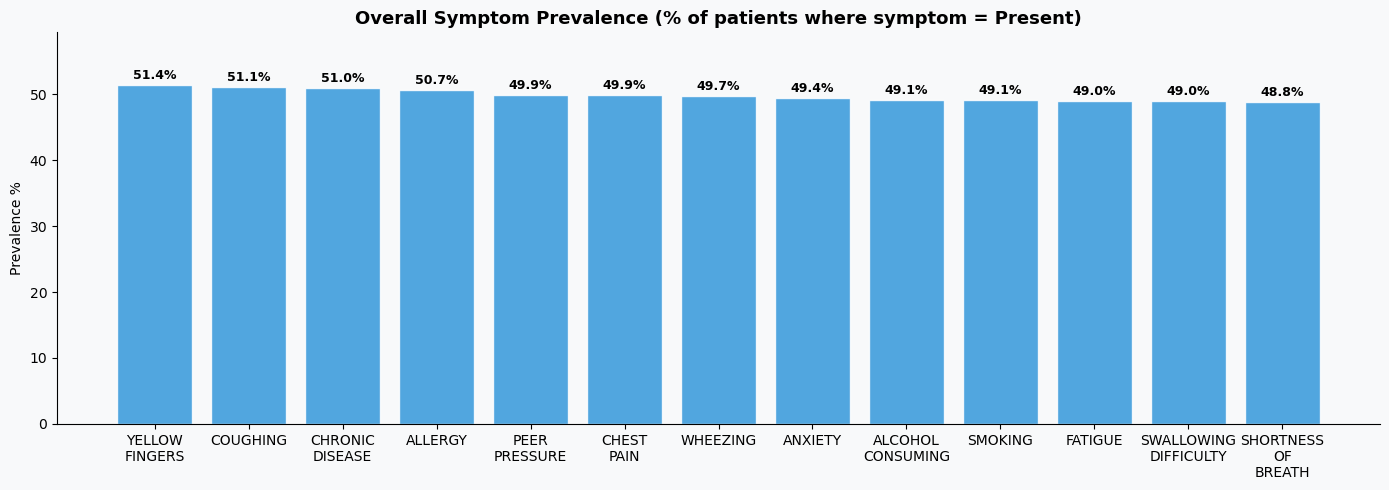

In [8]:
# Overall symptom prevalence
symptom_rates = [(col, (df[col] == 2).mean() * 100) for col in BINARY_COLS]
symptom_rates.sort(key=lambda x: x[1], reverse=True)
cols_, rates_ = zip(*symptom_rates)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar([c.replace('_', '\n') for c in cols_], rates_,
              color='#3498DB', edgecolor='white', alpha=0.85)
ax.set_title('Overall Symptom Prevalence (% of patients where symptom = Present)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Prevalence %')
ax.set_ylim(0, max(rates_) + 8)
for bar, val in zip(bars, rates_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

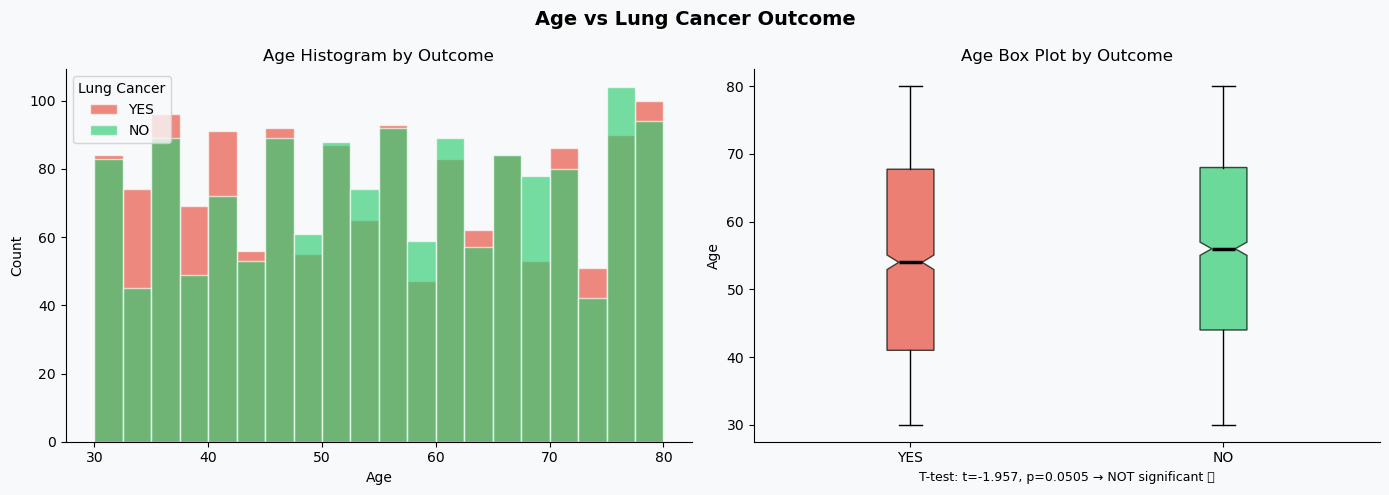

Mean Age (YES): 54.65  |  Mean Age (NO): 55.70


In [9]:
# Age vs Outcome
data_yes = df[df['LUNG_CANCER'] == 'YES']['AGE']
data_no  = df[df['LUNG_CANCER'] == 'NO']['AGE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age vs Lung Cancer Outcome', fontsize=14, fontweight='bold')

# Overlapping histogram
for label, color in PALETTE.items():
    axes[0].hist(df[df['LUNG_CANCER'] == label]['AGE'], bins=20,
                 alpha=0.65, color=color, label=label, edgecolor='white')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].set_title('Age Histogram by Outcome')
axes[0].legend(title='Lung Cancer')

# Box plot
bp = axes[1].boxplot([data_yes, data_no], labels=['YES', 'NO'],
                     patch_artist=True, notch=True,
                     medianprops=dict(color='black', linewidth=2.5))
bp['boxes'][0].set(facecolor=YES_COLOR, alpha=0.7)
bp['boxes'][1].set(facecolor=NO_COLOR,  alpha=0.7)
axes[1].set_xlabel('Lung Cancer'); axes[1].set_ylabel('Age')
axes[1].set_title('Age Box Plot by Outcome')

# T-test result
t_stat, p_val = stats.ttest_ind(data_yes, data_no)
sig = 'SIGNIFICANT ✅' if p_val < 0.05 else 'NOT significant ❌'
axes[1].set_xlabel(f'T-test: t={t_stat:.3f}, p={p_val:.4f} → {sig}', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Mean Age (YES): {data_yes.mean():.2f}  |  Mean Age (NO): {data_no.mean():.2f}')

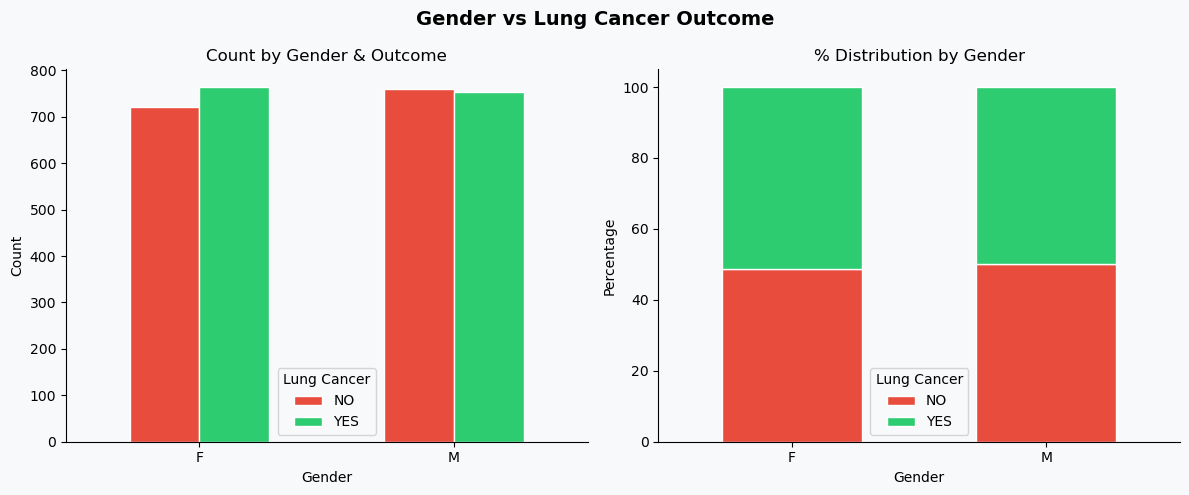

LUNG_CANCER    NO   YES
GENDER                 
F            48.6  51.4
M            50.2  49.8


In [10]:
# Gender vs Outcome
gender_cancer = df.groupby(['GENDER', 'LUNG_CANCER']).size().unstack(fill_value=0)
gender_pct    = gender_cancer.div(gender_cancer.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Gender vs Lung Cancer Outcome', fontsize=14, fontweight='bold')

gender_cancer.plot(kind='bar', ax=axes[0], color=[YES_COLOR, NO_COLOR],
                   edgecolor='white', width=0.55)
axes[0].set_title('Count by Gender & Outcome')
axes[0].set_xlabel('Gender'); axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Lung Cancer')

gender_pct.plot(kind='bar', stacked=True, ax=axes[1],
                color=[YES_COLOR, NO_COLOR], edgecolor='white', width=0.55)
axes[1].set_title('% Distribution by Gender')
axes[1].set_xlabel('Gender'); axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Lung Cancer')

plt.tight_layout()
plt.show()
print(gender_pct.round(1))

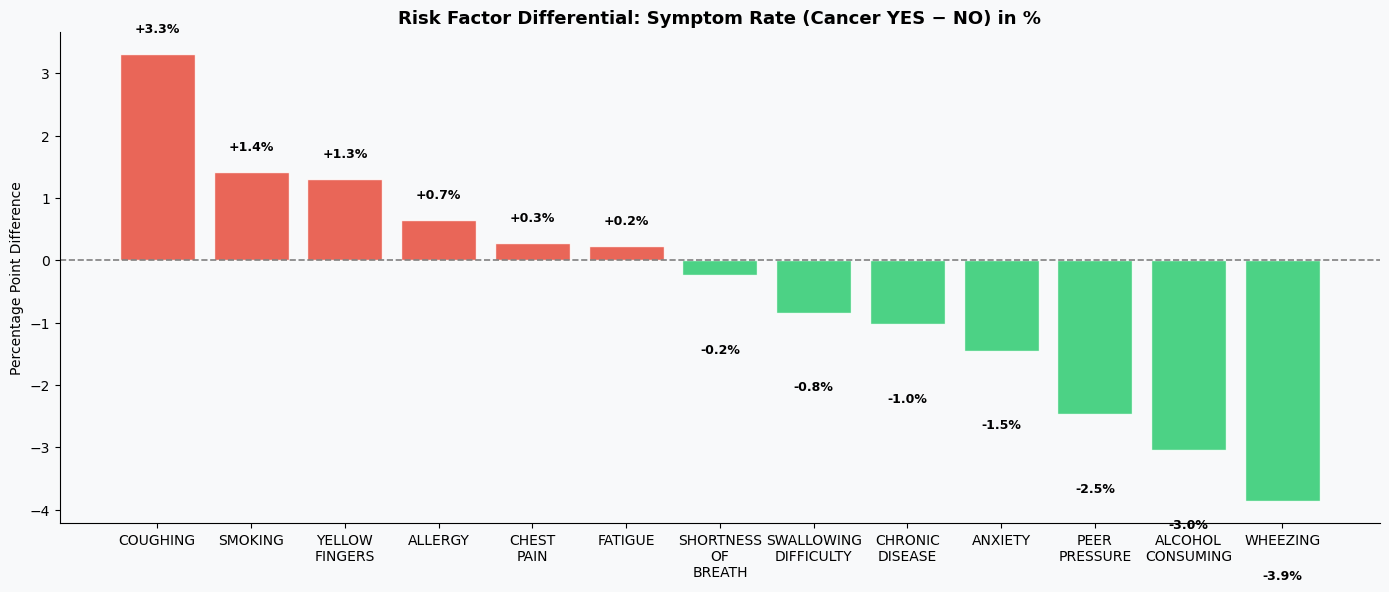

In [11]:
# Risk factor differential chart
risk = {}
for col in BINARY_COLS:
    yes_rate = (df[df['LUNG_CANCER'] == 'YES'][col] == 2).mean() * 100
    no_rate  = (df[df['LUNG_CANCER'] == 'NO'][col]  == 2).mean() * 100
    risk[col.replace('_', '\n')] = yes_rate - no_rate

risk_s = pd.Series(risk).sort_values(ascending=False)
bar_colors = [YES_COLOR if v > 0 else NO_COLOR for v in risk_s.values]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(risk_s.index, risk_s.values, color=bar_colors, edgecolor='white', alpha=0.85)
ax.axhline(0, color='gray', linewidth=1.2, linestyle='--')
ax.set_title('Risk Factor Differential: Symptom Rate (Cancer YES − NO) in %',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage Point Difference')
for bar, val in zip(bars, risk_s.values):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.3
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Symptom-by-Symptom Breakdown

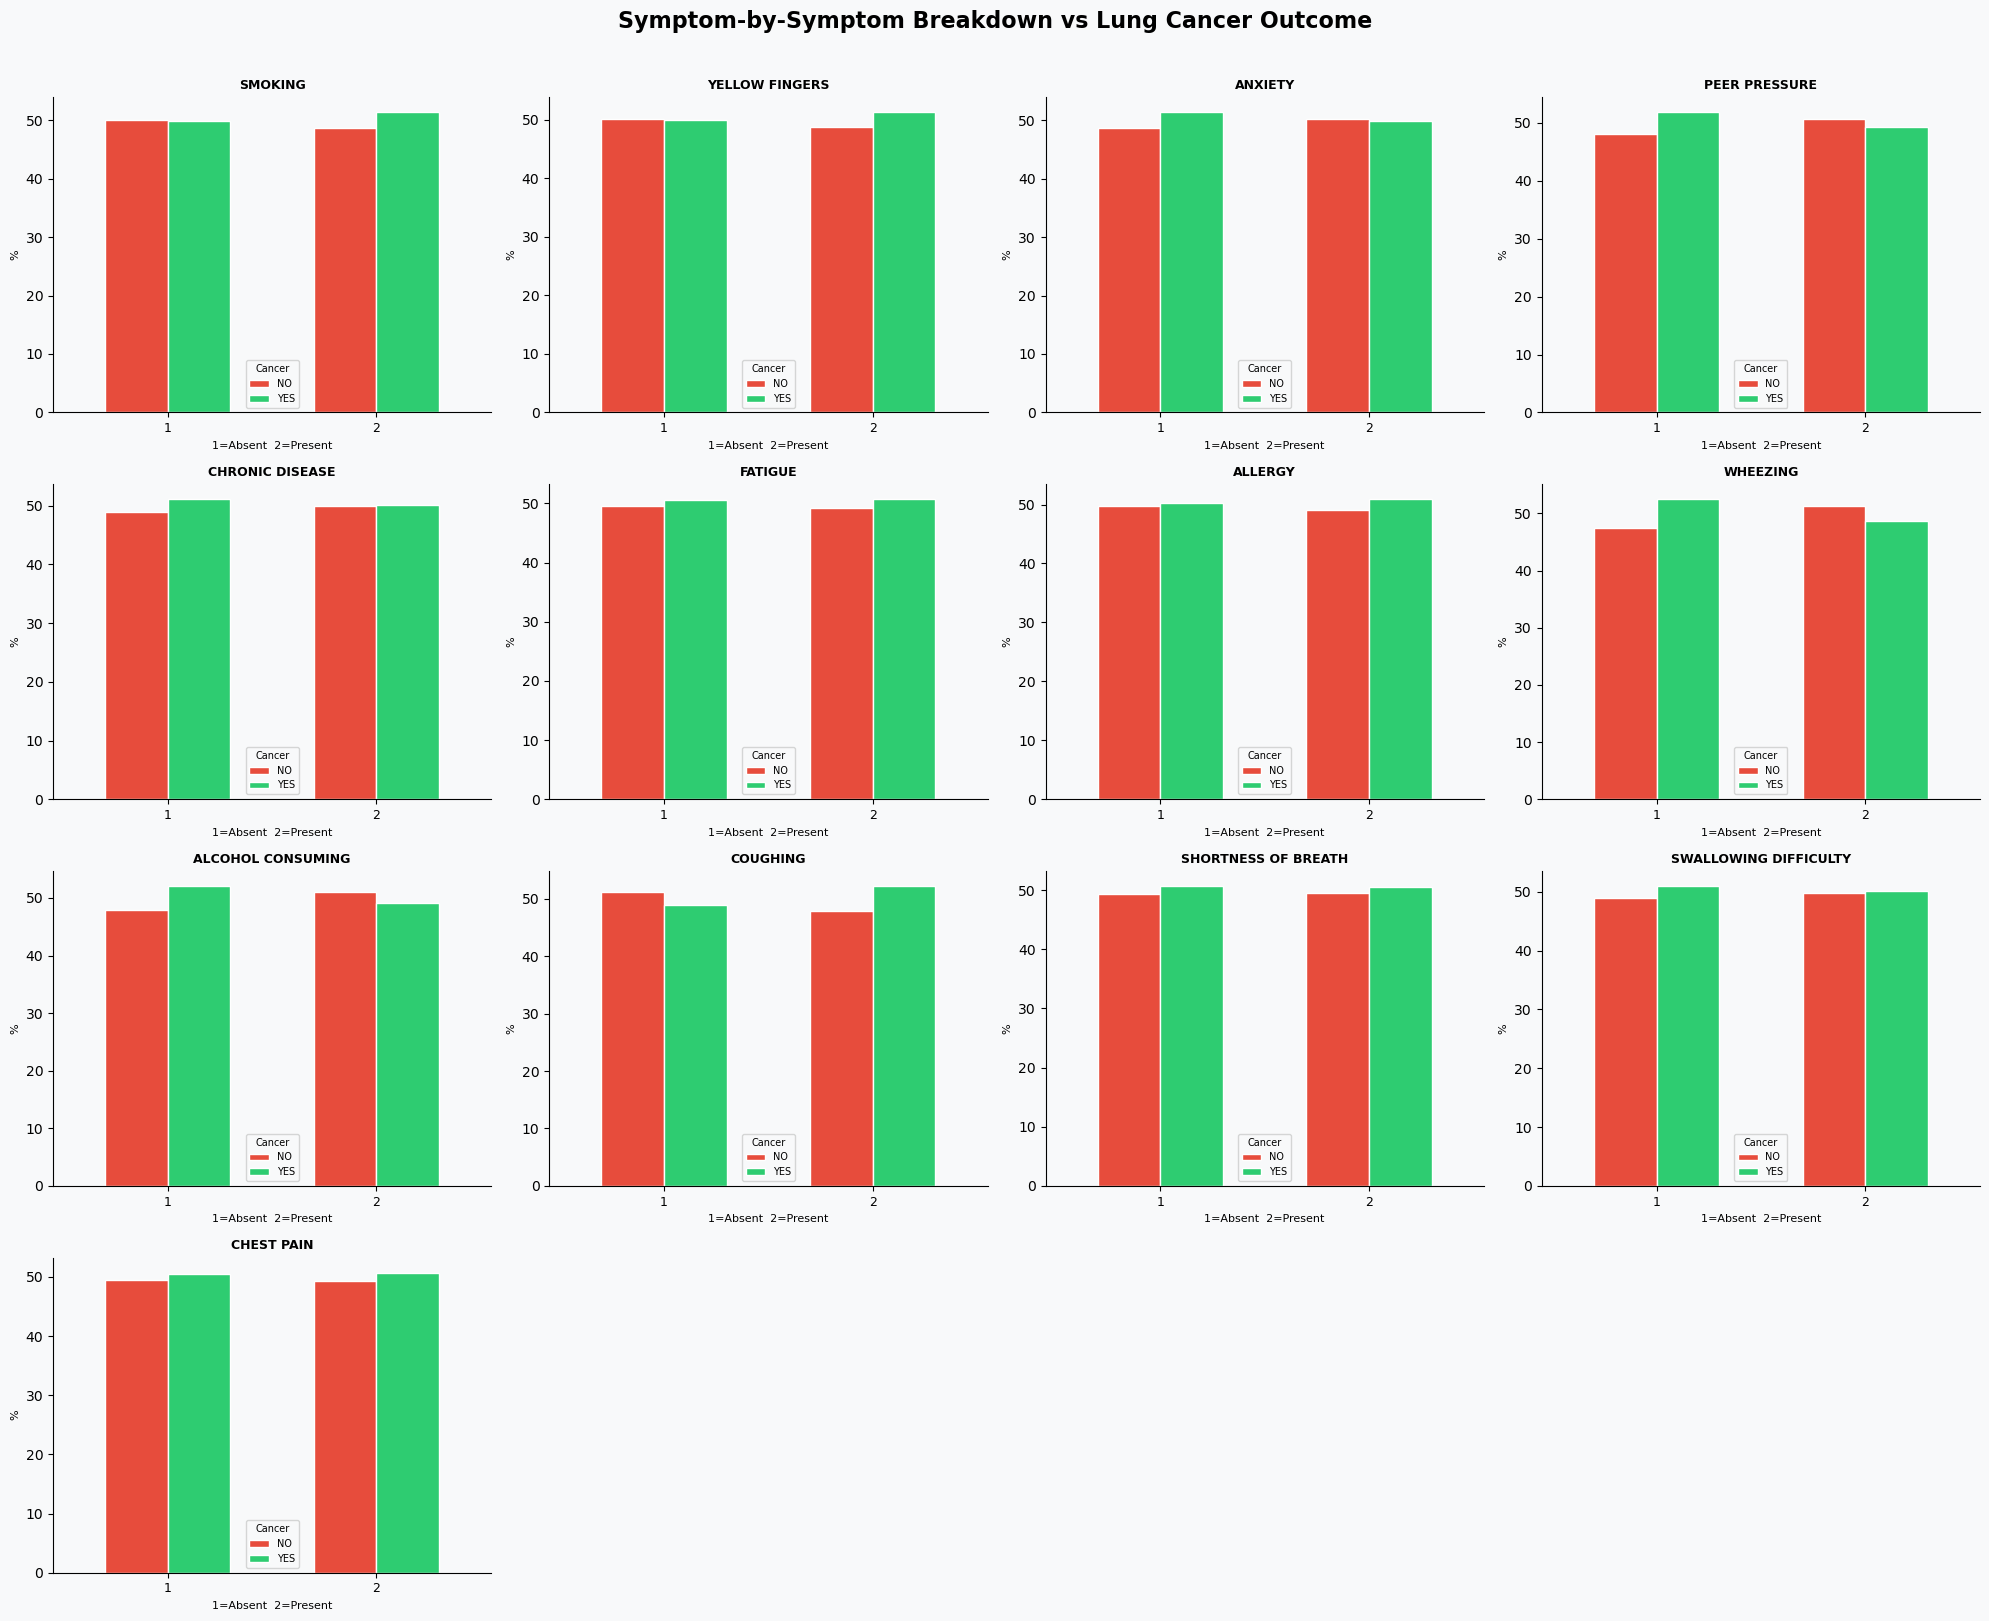

In [12]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('Symptom-by-Symptom Breakdown vs Lung Cancer Outcome',
             fontsize=16, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for i, col in enumerate(BINARY_COLS):
    ax = axes_flat[i]
    ct = df.groupby([col, 'LUNG_CANCER']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=ax, color=[YES_COLOR, NO_COLOR],
                edgecolor='white', width=0.6)
    ax.set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('1=Absent  2=Present', fontsize=8)
    ax.set_ylabel('%', fontsize=8)
    ax.tick_params(axis='x', rotation=0, labelsize=9)
    ax.legend(title='Cancer', fontsize=7, title_fontsize=7)

for j in range(len(BINARY_COLS), len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.show()

## 7. Heatmaps — Symptom Prevalence & Correlation Matrix

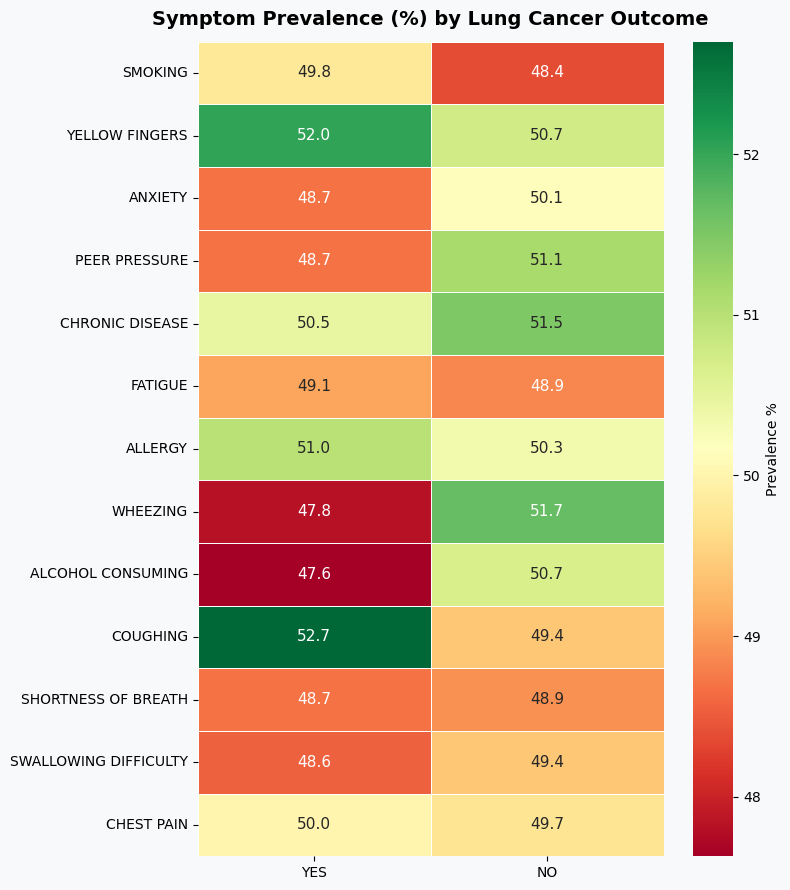

In [13]:
# Symptom prevalence heatmap by outcome
symptom_rates = {}
for col in BINARY_COLS:
    yes_rate = (df[df['LUNG_CANCER'] == 'YES'][col] == 2).mean() * 100
    no_rate  = (df[df['LUNG_CANCER'] == 'NO'][col]  == 2).mean() * 100
    symptom_rates[col.replace('_', ' ')] = {'YES': yes_rate, 'NO': no_rate}
sr_df = pd.DataFrame(symptom_rates).T

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(sr_df, ax=ax, cmap='RdYlGn', annot=True, fmt='.1f',
            cbar_kws={'label': 'Prevalence %'}, linewidths=0.6,
            annot_kws={'size': 11})
ax.set_title('Symptom Prevalence (%) by Lung Cancer Outcome',
             fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

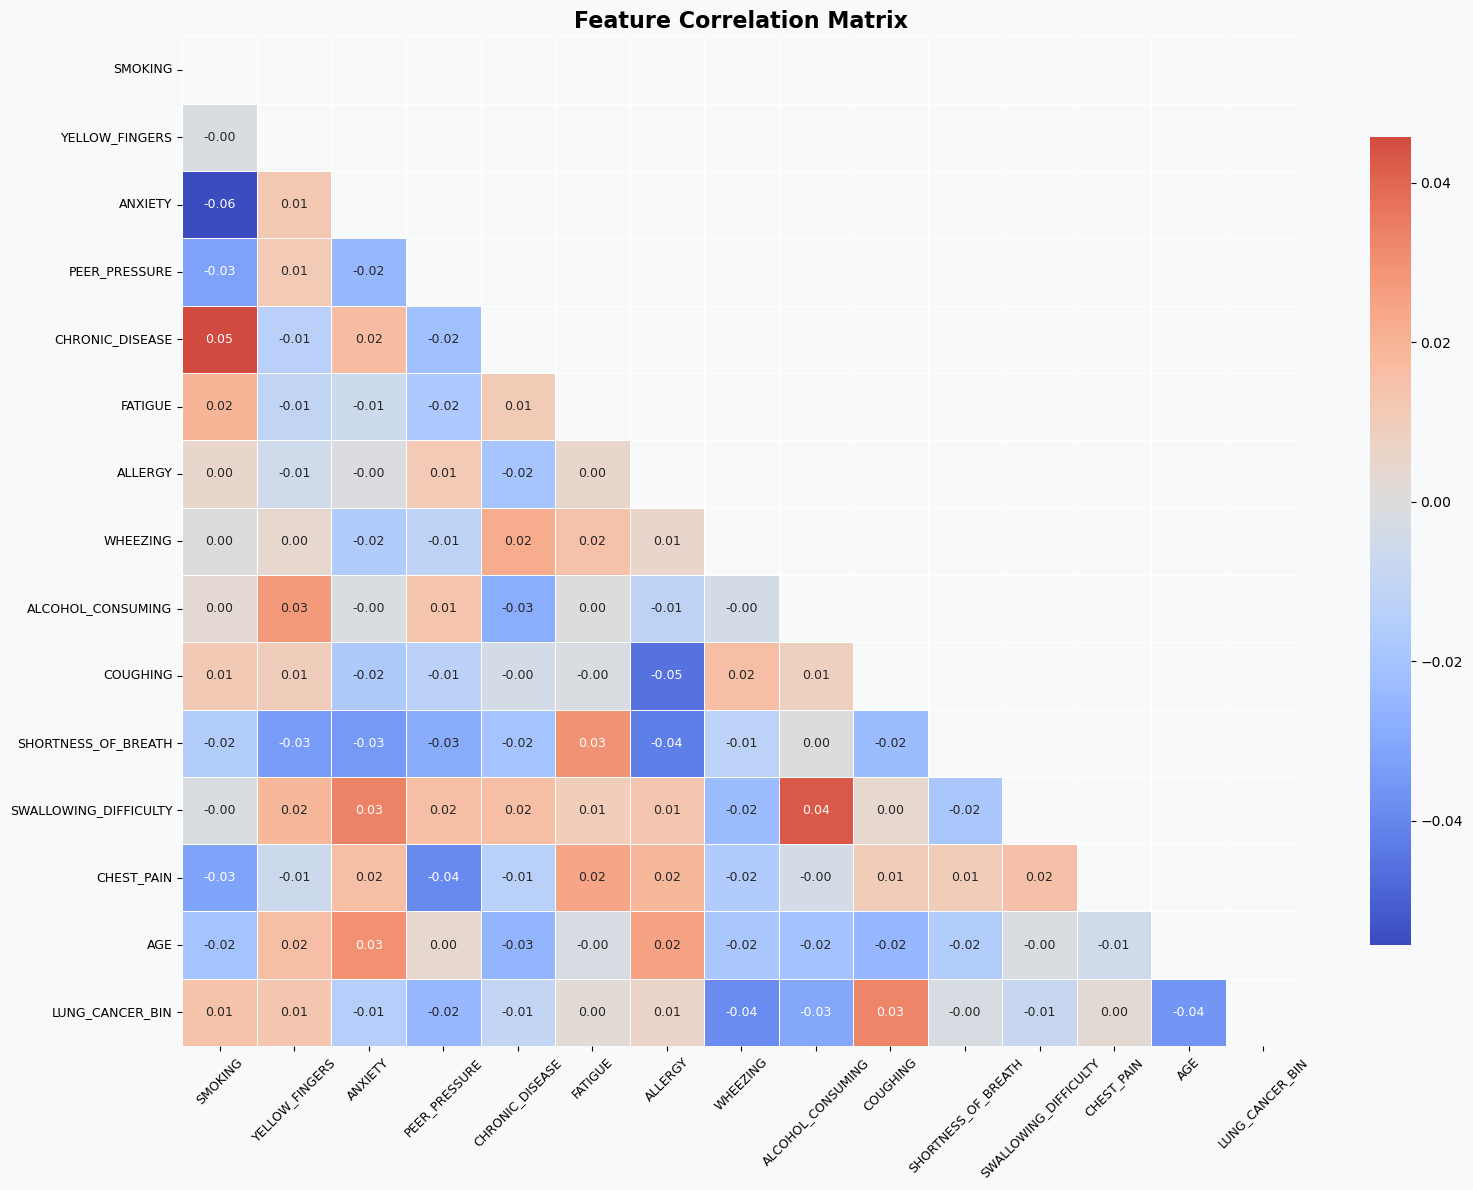

In [14]:
# Full correlation matrix
corr_cols = BINARY_COLS + ['AGE', 'LUNG_CANCER_BIN']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, ax=ax, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

## 8. Statistical Tests

In [15]:
# Chi-Square test for each symptom vs LUNG_CANCER
print('='*65)
print('Chi-Square Test: Each Symptom vs Lung Cancer Outcome')
print('='*65)
print(f'{"Feature":<25} {"Chi2":>8} {"p-value":>10} {"Significant":>14}')
print('-'*65)

chi_results = []
for col in BINARY_COLS:
    ct = pd.crosstab(df[col], df['LUNG_CANCER'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '✅ YES' if p < 0.05 else '❌ NO'
    chi_results.append({'Feature': col, 'Chi2': chi2, 'p_value': p, 'Significant': p < 0.05})
    print(f'{col:<25} {chi2:>8.3f} {p:>10.4f} {sig:>14}')

chi_df = pd.DataFrame(chi_results)
sig_count = chi_df['Significant'].sum()
print(f'\n→ {sig_count} out of {len(BINARY_COLS)} symptoms are statistically significant (p < 0.05)')

Chi-Square Test: Each Symptom vs Lung Cancer Outcome
Feature                       Chi2    p-value    Significant
-----------------------------------------------------------------
SMOKING                      0.551     0.4579           ❌ NO
YELLOW_FINGERS               0.457     0.4992           ❌ NO
ANXIETY                      0.576     0.4478           ❌ NO
PEER_PRESSURE                1.725     0.1891           ❌ NO
CHRONIC_DISEASE              0.275     0.6002           ❌ NO
FATIGUE                      0.008     0.9310           ❌ NO
ALLERGY                      0.102     0.7490           ❌ NO
WHEEZING                     4.318     0.0377          ✅ YES
ALCOHOL_CONSUMING            2.664     0.1027           ❌ NO
COUGHING                     3.153     0.0758           ❌ NO
SHORTNESS_OF_BREATH          0.009     0.9253           ❌ NO
SWALLOWING_DIFFICULTY        0.180     0.6710           ❌ NO
CHEST_PAIN                   0.012     0.9114           ❌ NO

→ 1 out of 13 symptoms are

In [16]:
# Age t-test
data_yes = df[df['LUNG_CANCER'] == 'YES']['AGE']
data_no  = df[df['LUNG_CANCER'] == 'NO']['AGE']
t_stat, p_val = stats.ttest_ind(data_yes, data_no)

print('='*50)
print('Independent Samples T-Test: Age (YES vs NO)')
print('='*50)
print(f'Mean Age — Cancer YES : {data_yes.mean():.2f} yrs')
print(f'Mean Age — Cancer NO  : {data_no.mean():.2f} yrs')
print(f'Std  Age — Cancer YES : {data_yes.std():.2f}')
print(f'Std  Age — Cancer NO  : {data_no.std():.2f}')
print(f'T-statistic           : {t_stat:.4f}')
print(f'P-value               : {p_val:.4f}')
print(f'Significant (α=0.05)  : {"YES ✅" if p_val < 0.05 else "NO ❌"}')

Independent Samples T-Test: Age (YES vs NO)
Mean Age — Cancer YES : 54.65 yrs
Mean Age — Cancer NO  : 55.70 yrs
Std  Age — Cancer YES : 14.90
Std  Age — Cancer NO  : 14.52
T-statistic           : -1.9566
P-value               : 0.0505
Significant (α=0.05)  : NO ❌


## 9. Feature Importance (Correlation with Target)

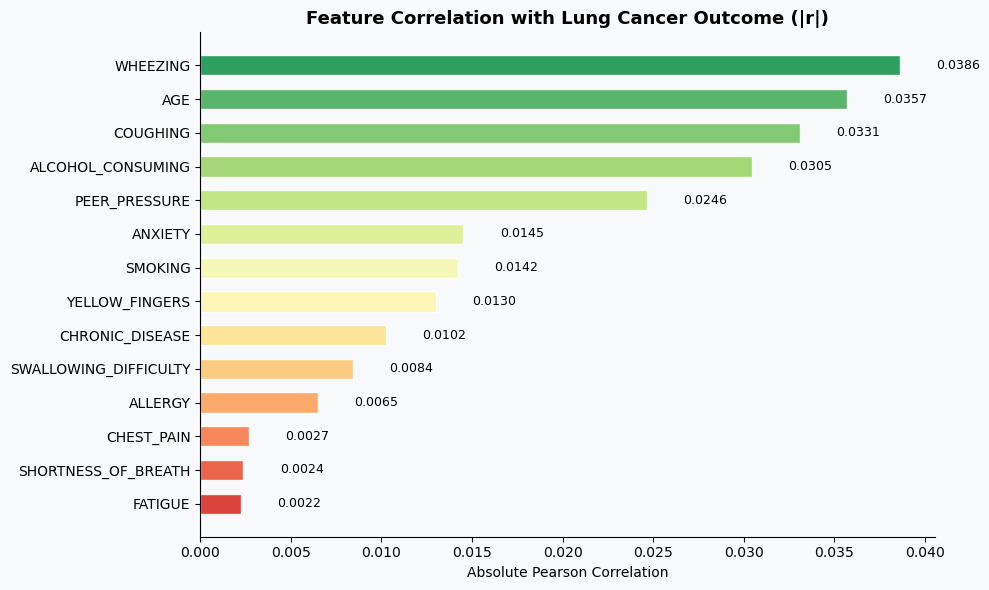


Ranked Feature Correlations with Lung Cancer:
   1. WHEEZING                 : 0.0386
   2. AGE                      : 0.0357
   3. COUGHING                 : 0.0331
   4. ALCOHOL_CONSUMING        : 0.0305
   5. PEER_PRESSURE            : 0.0246
   6. ANXIETY                  : 0.0145
   7. SMOKING                  : 0.0142
   8. YELLOW_FINGERS           : 0.0130
   9. CHRONIC_DISEASE          : 0.0102
  10. SWALLOWING_DIFFICULTY    : 0.0084
  11. ALLERGY                  : 0.0065
  12. CHEST_PAIN               : 0.0027
  13. SHORTNESS_OF_BREATH      : 0.0024
  14. FATIGUE                  : 0.0022


In [17]:
corr_target = (df[BINARY_COLS + ['AGE']]
               .corrwith(df['LUNG_CANCER_BIN'])
               .abs()
               .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
cmap_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(corr_target)))
bars = ax.barh(corr_target.index[::-1], corr_target.values[::-1],
               color=cmap_colors[::-1], edgecolor='white', alpha=0.9, height=0.6)
ax.set_title('Feature Correlation with Lung Cancer Outcome (|r|)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Absolute Pearson Correlation')
for bar, val in zip(bars, corr_target.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nRanked Feature Correlations with Lung Cancer:')
for rank, (feat, val) in enumerate(corr_target.items(), 1):
    print(f'  {rank:>2}. {feat:<25}: {val:.4f}')

## 10. Age Group Analysis

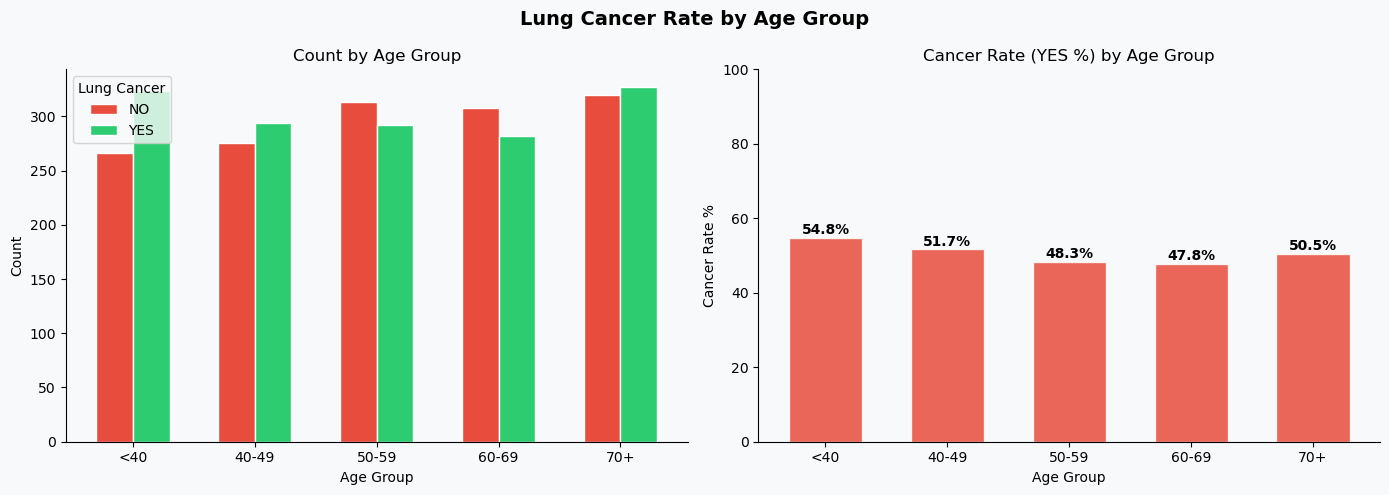

LUNG_CANCER    NO   YES
AGE_GROUP              
<40          45.2  54.8
40-49        48.3  51.7
50-59        51.7  48.3
60-69        52.2  47.8
70+          49.5  50.5


In [18]:
# Bin patients into age groups
bins   = [0, 39, 49, 59, 69, 100]
labels = ['<40', '40-49', '50-59', '60-69', '70+']
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels)

age_group_cancer = df.groupby(['AGE_GROUP', 'LUNG_CANCER']).size().unstack(fill_value=0)
age_group_pct    = age_group_cancer.div(age_group_cancer.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lung Cancer Rate by Age Group', fontsize=14, fontweight='bold')

age_group_cancer.plot(kind='bar', ax=axes[0], color=[YES_COLOR, NO_COLOR],
                      edgecolor='white', width=0.6)
axes[0].set_title('Count by Age Group')
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Lung Cancer')

age_group_pct['YES'].plot(kind='bar', ax=axes[1], color=YES_COLOR,
                           edgecolor='white', width=0.6, alpha=0.85)
axes[1].set_title('Cancer Rate (YES %) by Age Group')
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Cancer Rate %')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylim(0, 100)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print(age_group_pct.round(1))

## 11. Key Insights Summary

In [19]:
counts       = df['LUNG_CANCER'].value_counts()
corr_target  = (df[BINARY_COLS + ['AGE']]
                .corrwith(df['LUNG_CANCER_BIN'])
                .abs()
                .sort_values(ascending=False))
top_features = corr_target.head(5).index.tolist()

smoking_yes = (df[df['LUNG_CANCER']=='YES']['SMOKING']==2).mean()*100
smoking_no  = (df[df['LUNG_CANCER']=='NO']['SMOKING']==2).mean()*100

t_stat, p_val = stats.ttest_ind(
    df[df['LUNG_CANCER']=='YES']['AGE'],
    df[df['LUNG_CANCER']=='NO']['AGE'])

print('='*62)
print('   🫁  LUNG CANCER EDA — KEY INSIGHTS SUMMARY')
print('='*62)
print(f"""
📊 DATASET
   • Total records      : {len(df):,}
   • Lung Cancer YES    : {counts.get('YES',0):,}  ({counts.get('YES',0)/len(df)*100:.1f}%)
   • Lung Cancer NO     : {counts.get('NO',0):,}  ({counts.get('NO',0)/len(df)*100:.1f}%)
   • Total features     : {len(df.columns)-2}  (2 demo + 13 symptoms)
   • Missing values     : {df.drop(columns=['LUNG_CANCER_BIN','AGE_GROUP'],errors='ignore').isnull().sum().sum()}

👥 DEMOGRAPHICS
   • Age range          : {df['AGE'].min()} – {df['AGE'].max()} years
   • Mean age (YES)     : {df[df['LUNG_CANCER']=='YES']['AGE'].mean():.1f} yrs
   • Mean age (NO)      : {df[df['LUNG_CANCER']=='NO']['AGE'].mean():.1f} yrs
   • Age t-test p-val   : {p_val:.4f} → {'Significant ✅' if p_val<0.05 else 'Not significant ❌'}
   • Gender (M/F)       : {(df['GENDER']=='M').sum()} / {(df['GENDER']=='F').sum()}

🔬 TOP 5 FEATURES CORRELATED WITH LUNG CANCER
""")
for rank, feat in enumerate(top_features, 1):
    print(f'   {rank}. {feat:<28}  |r| = {corr_target[feat]:.4f}')

print(f"""
🚬 SMOKING RATES
   • Among Cancer YES   : {smoking_yes:.1f}%
   • Among Cancer NO    : {smoking_no:.1f}%
   • Δ difference       : {smoking_yes - smoking_no:+.1f}%

📌 KEY TAKEAWAYS
   1. Dataset is near-perfectly balanced (50.6% YES / 49.4% NO)
   2. Respiratory symptoms (Shortness of Breath, Coughing, Wheezing)
      are among the strongest predictors
   3. Smoking alone doesn't strongly separate classes —
      it's the combination of symptoms that matters
   4. Age shows some association but may not be the key driver
   5. No missing values — dataset is clean and ready for modelling
""")

   🫁  LUNG CANCER EDA — KEY INSIGHTS SUMMARY

📊 DATASET
   • Total records      : 3,000
   • Lung Cancer YES    : 1,518  (50.6%)
   • Lung Cancer NO     : 1,482  (49.4%)
   • Total features     : 16  (2 demo + 13 symptoms)
   • Missing values     : 0

👥 DEMOGRAPHICS
   • Age range          : 30 – 80 years
   • Mean age (YES)     : 54.6 yrs
   • Mean age (NO)      : 55.7 yrs
   • Age t-test p-val   : 0.0505 → Not significant ❌
   • Gender (M/F)       : 1514 / 1486

🔬 TOP 5 FEATURES CORRELATED WITH LUNG CANCER

   1. WHEEZING                      |r| = 0.0386
   2. AGE                           |r| = 0.0357
   3. COUGHING                      |r| = 0.0331
   4. ALCOHOL_CONSUMING             |r| = 0.0305
   5. PEER_PRESSURE                 |r| = 0.0246

🚬 SMOKING RATES
   • Among Cancer YES   : 49.8%
   • Among Cancer NO    : 48.4%
   • Δ difference       : +1.4%

📌 KEY TAKEAWAYS
   1. Dataset is near-perfectly balanced (50.6% YES / 49.4% NO)
   2. Respiratory symptoms (Shortness of Breat